# DA-19: Food Delivery Orders Analysis

**Student Name:** Samson Mayomi Matthew
**Fellow ID:** FE/23/45701487
**Program:** 3MTT NextGen Fellow — Capstone Project (Brief DA-19)
**Data Source:** Synthetic Data (Simulated Lagos Food Delivery Operations)
**Dataset:** `Nigerian_Food_Delivery_Orders.csv`

## Primary Objective
Provide actionable operational, spatial, and financial insights for food delivery vendors and platform operators to address order bottlenecks, peak-hour delays, and cancellation trends across Lagos delivery zones.

---

## Notebook Roadmap
1. Environment Setup & Data Loading
2. Data Preprocessing & Feature Engineering
3. Exploratory Data Analysis (EDA) & Visualizations
4. Executive Insights Summary & Business Metrics
5. Strategic Business Recommendations
6. Dataset Export (for Power BI / Tableau)


## Step 1: Environment Setup & Data Loading

We import the core analytics stack (`pandas`, `numpy`, `matplotlib`, `seaborn`, `datetime`), configure a consistent visual theme for all charts in this notebook, then load and perform an initial inspection of the raw dataset.

In [1]:
# ---------------------------------------------------------
# 1.1 Import required libraries
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1.2 Global visual style — professional, publication-ready
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.family"] = "DejaVu Sans"

# Custom brand palette (Naija food-delivery theme: green / amber / charcoal)
BRAND_PALETTE = ["#1B7A43", "#F2A104", "#2C3E50", "#E74C3C", "#3498DB", "#9B59B6"]
sns.set_palette(sns.color_palette(BRAND_PALETTE))

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported and plotting theme configured successfully.")

Libraries imported and plotting theme configured successfully.


In [2]:
# ---------------------------------------------------------
# 1.3 Load the dataset
# ---------------------------------------------------------
DATA_PATH = "Nigerian_Food_Delivery_Orders.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully -> {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(10)

Dataset loaded successfully -> 1,500 rows x 13 columns


,Order_ID,Order_Timestamp,Delivery_Zone,Cuisine_Type,Item_Name,Item_Price_NGN,Delivery_Fee_NGN,Discount_NGN,Total_Amount_NGN,Prep_Time_Min,Delivery_Time_Min,Order_Status,Customer_Rating
0,ORD-2026-1000,2026-06-08 17:42:07,Gbagada,Fast Food,Crispy Chicken Wings,12000,800,1000,11800,23,33,Delivered,3.6
1,ORD-2026-1001,2026-05-21 14:22:10,Ikeja,Local Delicacies,Jollof Rice & Fried Chicken,4500,800,0,5300,10,36,Delivered,4.6
2,ORD-2026-1002,2026-05-11 11:39:23,Yaba,Grills & Suya,BBQ Chicken Quarters,3500,800,0,4300,14,27,Delivered,4.6
3,ORD-2026-1003,2026-05-03 13:23:43,Yaba,Local Delicacies,Amala & Abula,6500,1500,1000,7000,26,30,Delivered,4.2
4,ORD-2026-1004,2026-05-30 18:20:32,Victoria Island,Fast Food,Shawarma Special,4500,1200,0,5700,17,35,Delivered,4.0
5,ORD-2026-1005,2026-05-12 19:43:24,Victoria Island,Local Delicacies,Pounded Yam & Egusi,3500,1500,1000,4000,15,48,Delivered,4.1
6,ORD-2026-1006,2026-06-18 21:41:27,Ikeja,Grills & Suya,BBQ Chicken Quarters,12000,800,500,12300,20,23,Delivered,4.1
7,ORD-2026-1007,2026-06-29 20:46:50,Ikeja,Local Delicacies,Pounded Yam & Egusi,12000,2000,0,14000,19,44,Delivered,3.7
8,ORD-2026-1008,2026-06-13 12:02:36,Gbagada,Local Delicacies,Amala & Abula,4500,800,0,5300,24,39,Cancelled,NaN
9,ORD-2026-1009,2026-06-20 08:38:17,Yaba,Local Delicacies,Jollof Rice & Fried Chicken,6500,1000,500,7000,22,30,Delivered,3.6


In [3]:
# ---------------------------------------------------------
# 1.4 Structural overview
# ---------------------------------------------------------
print("=" * 70)
print("DATASET INFO")
print("=" * 70)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           1500 non-null   str    
 1   Order_Timestamp    1500 non-null   str    
 2   Delivery_Zone      1500 non-null   str    
 3   Cuisine_Type       1500 non-null   str    
 4   Item_Name          1500 non-null   str    
 5   Item_Price_NGN     1500 non-null   int64  
 6   Delivery_Fee_NGN   1500 non-null   int64  
 7   Discount_NGN       1500 non-null   int64  
 8   Total_Amount_NGN   1500 non-null   int64  
 9   Prep_Time_Min      1500 non-null   int64  
 10  Delivery_Time_Min  1500 non-null   int64  
 11  Order_Status       1500 non-null   str    
 12  Customer_Rating    1361 non-null   float64
dtypes: float64(1), int64(6), str(6)
memory usage: 152.5 KB


In [4]:
# ---------------------------------------------------------
# 1.5 Statistical summary (numeric columns)
# ---------------------------------------------------------
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Item_Price_NGN,1500.0,6524.666667,2775.823305,3500.0,4500.0,5000.0,8000.0,12000.0
Delivery_Fee_NGN,1500.0,1289.000000,424.914935,800.0,1000.0,1200.0,1500.0,2000.0
Discount_NGN,1500.0,60.666667,201.692858,0.0,0.0,0.0,0.0,1000.0
Total_Amount_NGN,1500.0,7753.000000,2825.597341,3300.0,5500.0,7000.0,9000.0,14000.0
Prep_Time_Min,1500.0,19.571333,4.908188,10.0,16.0,20.0,23.0,35.0
Delivery_Time_Min,1500.0,34.330667,9.915856,15.0,27.0,34.0,41.0,70.0
Customer_Rating,1361.0,4.232403,0.431363,3.5,3.9,4.2,4.6,5.0


In [5]:
# ---------------------------------------------------------
# 1.6 Categorical column overview
# ---------------------------------------------------------
categorical_cols = ["Delivery_Zone", "Cuisine_Type", "Order_Status"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Delivery_Zone ---
Delivery_Zone
Lekki Phase 1      370
Ikeja              359
Victoria Island    300
Yaba               179
Surulere           150
Gbagada            142
Name: count, dtype: int64

--- Cuisine_Type ---
Cuisine_Type
Local Delicacies    640
Fast Food           397
Grills & Suya       302
Continental         161
Name: count, dtype: int64

--- Order_Status ---
Order_Status
Delivered     1361
Cancelled       99
In Transit      40
Name: count, dtype: int64


## Step 2: Data Preprocessing & Feature Engineering

**Data quality note:** `Customer_Rating` is null for orders that were **Cancelled** or are still **In Transit** — this is expected business logic (a customer cannot rate an order they never received), not a data quality defect. We preserve these as `NaN` for rating-specific analysis, but add a `Has_Rating` flag so cancellations/in-transit orders are never silently dropped from operational counts.

Steps performed:
1. Handle missing values in `Customer_Rating` (flag rather than impute, since imputing a rating for an undelivered order would be misleading).
2. Convert `Order_Timestamp` to proper `datetime` dtype.
3. Engineer time-based features: `Order_Hour`, `Day_of_Week`, `Is_Weekend`, `Peak_Period`.
4. Engineer financial KPI features: `Gross_Revenue`, `Net_Revenue_Post_Discount`, `Discount_Rate_%`.

In [6]:
# ---------------------------------------------------------
# 2.1 Missing value audit
# ---------------------------------------------------------
missing_summary = df.isnull().sum().to_frame("Missing_Count")
missing_summary["Missing_%"] = (missing_summary["Missing_Count"] / len(df) * 100).round(2)
missing_summary = missing_summary[missing_summary["Missing_Count"] > 0]
print("Columns with missing values:")
missing_summary

Columns with missing values:


,Missing_Count,Missing_%
Customer_Rating,139,9.27


In [7]:
# ---------------------------------------------------------
# 2.2 Cross-check: missing ratings vs. order status
# Confirms that nulls are concentrated in Cancelled / In Transit orders
# ---------------------------------------------------------
rating_null_by_status = (
    df.assign(Rating_Missing=df["Customer_Rating"].isnull())
      .groupby("Order_Status")["Rating_Missing"]
      .agg(["sum", "count"])
      .rename(columns={"sum": "Missing_Ratings", "count": "Total_Orders"})
)
rating_null_by_status["Missing_%"] = (
    rating_null_by_status["Missing_Ratings"] / rating_null_by_status["Total_Orders"] * 100
).round(1)
rating_null_by_status

,Missing_Ratings,Total_Orders,Missing_%
Order_Status,,,
Cancelled,99,99,100.0
Delivered,0,1361,0.0
In Transit,40,40,100.0


In [8]:
# ---------------------------------------------------------
# 2.3 Handle missing values
# Business rule: a null rating on a Cancelled/In-Transit order is VALID
# (no delivery occurred yet), so we do NOT impute a numeric rating.
# Instead we add a boolean flag for clean downstream aggregation.
# ---------------------------------------------------------
df["Has_Rating"] = df["Customer_Rating"].notna()

# Sanity check: are there any nulls in a *Delivered* order? (would indicate a real data issue)
unexpected_nulls = df[(df["Order_Status"] == "Delivered") & (df["Customer_Rating"].isnull())]
print(f"Unexpected missing ratings on Delivered orders: {len(unexpected_nulls)}")

# Duplicate / ID integrity check
print(f"Duplicate Order_IDs: {df['Order_ID'].duplicated().sum()}")

Unexpected missing ratings on Delivered orders: 0
Duplicate Order_IDs: 0


In [9]:
# ---------------------------------------------------------
# 2.4 Data type correction — parse timestamp
# ---------------------------------------------------------
df["Order_Timestamp"] = pd.to_datetime(df["Order_Timestamp"], errors="coerce")

print(f"Timestamp parse failures: {df['Order_Timestamp'].isnull().sum()}")
print(f"Date range: {df['Order_Timestamp'].min()}  ->  {df['Order_Timestamp'].max()}")
df["Order_Timestamp"].head()

Timestamp parse failures: 0
Date range: 2026-05-01 10:29:10  ->  2026-06-29 22:43:54


0   2026-06-08 17:42:07
1   2026-05-21 14:22:10
2   2026-05-11 11:39:23
3   2026-05-03 13:23:43
4   2026-05-30 18:20:32
Name: Order_Timestamp, dtype: datetime64[us]

In [10]:
# ---------------------------------------------------------
# 2.5 Feature Engineering — time-based features
# ---------------------------------------------------------
df["Order_Hour"] = df["Order_Timestamp"].dt.hour
df["Order_Date"] = df["Order_Timestamp"].dt.date
df["Day_of_Week"] = df["Order_Timestamp"].dt.day_name()
df["Is_Weekend"] = df["Order_Timestamp"].dt.dayofweek.isin([5, 6])  # Sat=5, Sun=6

def classify_peak_period(hour):
    # Classify an order hour into Lunch / Dinner / Off-Peak bands.
    if 12 <= hour <= 15:
        return "Lunch"
    elif 18 <= hour <= 21:
        return "Dinner"
    else:
        return "Off-Peak"

df["Peak_Period"] = df["Order_Hour"].apply(classify_peak_period)

# Order Day_of_Week categorically so charts render Mon->Sun
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Day_of_Week"] = pd.Categorical(df["Day_of_Week"], categories=day_order, ordered=True)

df[["Order_Timestamp", "Order_Hour", "Day_of_Week", "Is_Weekend", "Peak_Period"]].head(10)

,Order_Timestamp,Order_Hour,Day_of_Week,Is_Weekend,Peak_Period
0,2026-06-08 17:42:07,17,Monday,False,Off-Peak
1,2026-05-21 14:22:10,14,Thursday,False,Lunch
2,2026-05-11 11:39:23,11,Monday,False,Off-Peak
3,2026-05-03 13:23:43,13,Sunday,True,Lunch
4,2026-05-30 18:20:32,18,Saturday,True,Dinner
5,2026-05-12 19:43:24,19,Tuesday,False,Dinner
6,2026-06-18 21:41:27,21,Thursday,False,Dinner
7,2026-06-29 20:46:50,20,Monday,False,Dinner
8,2026-06-13 12:02:36,12,Saturday,True,Lunch
9,2026-06-20 08:38:17,8,Saturday,True,Off-Peak


In [11]:
# ---------------------------------------------------------
# 2.6 Feature Engineering — financial KPI features
# ---------------------------------------------------------
# Gross_Revenue: full pre-discount value of the order (item + delivery fee)
df["Gross_Revenue"] = df["Item_Price_NGN"] + df["Delivery_Fee_NGN"]

# Net_Revenue_Post_Discount: actual amount charged to the customer after discount
df["Net_Revenue_Post_Discount"] = df["Gross_Revenue"] - df["Discount_NGN"]

# Sanity check against the dataset's own Total_Amount_NGN column
mismatch = (df["Net_Revenue_Post_Discount"] != df["Total_Amount_NGN"]).sum()
print(f"Rows where computed Net_Revenue differs from Total_Amount_NGN: {mismatch}")

# Discount rate as a % of gross revenue (useful for discount-strategy analysis)
df["Discount_Rate_%"] = np.where(
    df["Gross_Revenue"] > 0,
    (df["Discount_NGN"] / df["Gross_Revenue"] * 100).round(2),
    0
)

# Total fulfilment time (kitchen + rider) — used in bottleneck analysis
df["Total_Fulfilment_Min"] = df["Prep_Time_Min"] + df["Delivery_Time_Min"]

df[["Item_Price_NGN", "Delivery_Fee_NGN", "Discount_NGN", "Gross_Revenue",
    "Net_Revenue_Post_Discount", "Total_Amount_NGN", "Discount_Rate_%",
    "Total_Fulfilment_Min"]].head(10)

Rows where computed Net_Revenue differs from Total_Amount_NGN: 0


,Item_Price_NGN,Delivery_Fee_NGN,Discount_NGN,Gross_Revenue,Net_Revenue_Post_Discount,Total_Amount_NGN,Discount_Rate_%,Total_Fulfilment_Min
0,12000,800,1000,12800,11800,11800,7.81,56
1,4500,800,0,5300,5300,5300,0.00,46
2,3500,800,0,4300,4300,4300,0.00,41
3,6500,1500,1000,8000,7000,7000,12.50,56
4,4500,1200,0,5700,5700,5700,0.00,52
5,3500,1500,1000,5000,4000,4000,20.00,63
6,12000,800,500,12800,12300,12300,3.91,43
7,12000,2000,0,14000,14000,14000,0.00,63
8,4500,800,0,5300,5300,5300,0.00,63
9,6500,1000,500,7500,7000,7000,6.67,52


In [12]:
# ---------------------------------------------------------
# 2.7 Final preprocessing checkpoint
# ---------------------------------------------------------
print("Final cleaned & engineered dataset shape:", df.shape)
print("\nNew columns added:")
new_cols = ["Has_Rating", "Order_Hour", "Order_Date", "Day_of_Week", "Is_Weekend",
            "Peak_Period", "Gross_Revenue", "Net_Revenue_Post_Discount",
            "Discount_Rate_%", "Total_Fulfilment_Min"]
print(new_cols)

df[new_cols].head()

Final cleaned & engineered dataset shape: (1500, 23)

New columns added:
['Has_Rating', 'Order_Hour', 'Order_Date', 'Day_of_Week', 'Is_Weekend', 'Peak_Period', 'Gross_Revenue', 'Net_Revenue_Post_Discount', 'Discount_Rate_%', 'Total_Fulfilment_Min']


,Has_Rating,Order_Hour,Order_Date,Day_of_Week,Is_Weekend,Peak_Period,Gross_Revenue,Net_Revenue_Post_Discount,Discount_Rate_%,Total_Fulfilment_Min
0,True,17,2026-06-08,Monday,False,Off-Peak,12800,11800,7.81,56
1,True,14,2026-05-21,Thursday,False,Lunch,5300,5300,0.00,46
2,True,11,2026-05-11,Monday,False,Off-Peak,4300,4300,0.00,41
3,True,13,2026-05-03,Sunday,True,Lunch,8000,7000,12.50,56
4,True,18,2026-05-30,Saturday,True,Dinner,5700,5700,0.00,52


## Step 3: Exploratory Data Analysis (EDA) & Visualizations

This section produces four groups of publication-ready visualizations:

1. **Peak Time Analysis** — hourly order distribution & revenue trends by day of week
2. **Geographical / Zone Analysis** — orders and revenue by delivery zone
3. **Menu & Cuisine Performance** — top cuisines/items by volume and average order value
4. **Operational Bottlenecks & Order Status** — prep vs. delivery time, cancellation patterns

### 3.1 Peak Time Analysis

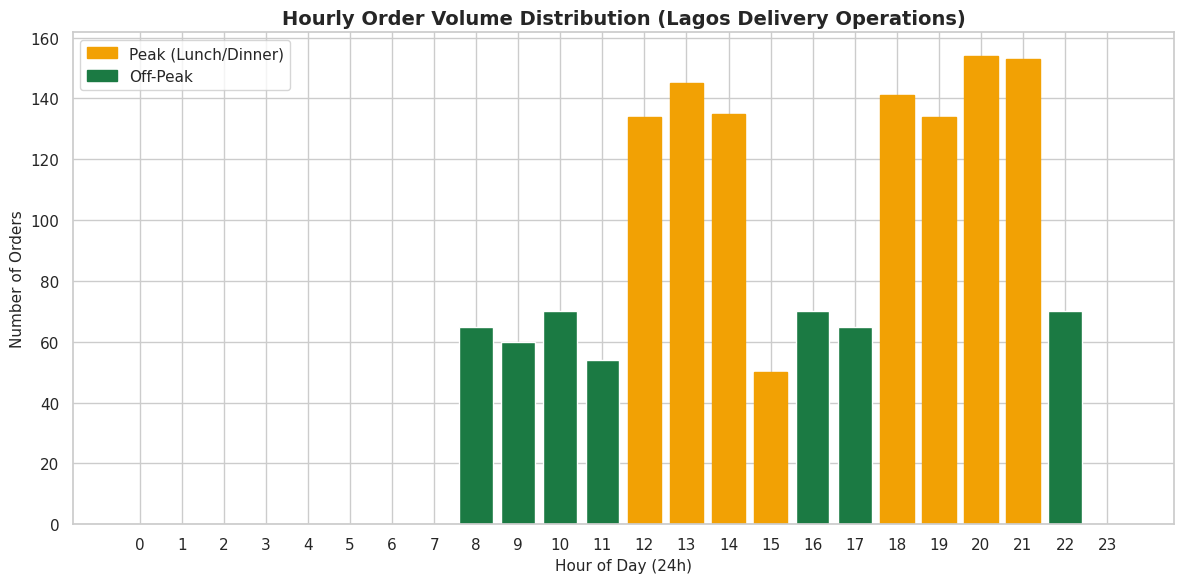

In [13]:
# ---------------------------------------------------------
# 3.1a Hourly order volume distribution
# ---------------------------------------------------------
hourly_orders = df.groupby("Order_Hour").size().reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(hourly_orders.index, hourly_orders.values, color=BRAND_PALETTE[0], edgecolor="white")

# Highlight peak bars
for i, bar in enumerate(bars):
    if 12 <= i <= 15 or 18 <= i <= 21:
        bar.set_color(BRAND_PALETTE[1])

ax.set_title("Hourly Order Volume Distribution (Lagos Delivery Operations)")
ax.set_xlabel("Hour of Day (24h)")
ax.set_ylabel("Number of Orders")
ax.set_xticks(range(24))
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=BRAND_PALETTE[1], label="Peak (Lunch/Dinner)"),
        plt.Rectangle((0, 0), 1, 1, color=BRAND_PALETTE[0], label="Off-Peak"),
    ],
    loc="upper left"
)
plt.tight_layout()
plt.show()

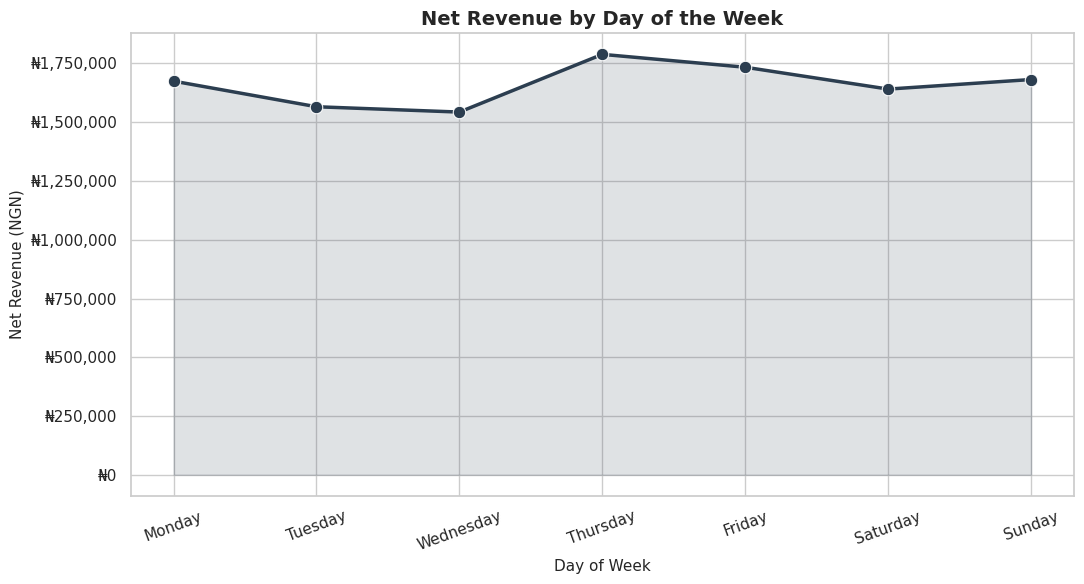

In [14]:
# ---------------------------------------------------------
# 3.1b Revenue trend across days of the week
# ---------------------------------------------------------
daily_revenue = df.groupby("Day_of_Week", observed=True)["Net_Revenue_Post_Discount"].sum()

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(x=daily_revenue.index, y=daily_revenue.values, marker="o",
             linewidth=2.5, markersize=9, color=BRAND_PALETTE[2], ax=ax)
ax.fill_between(range(len(daily_revenue)), daily_revenue.values, alpha=0.15, color=BRAND_PALETTE[2])

ax.set_title("Net Revenue by Day of the Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Net Revenue (NGN)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₦{x:,.0f}"))
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

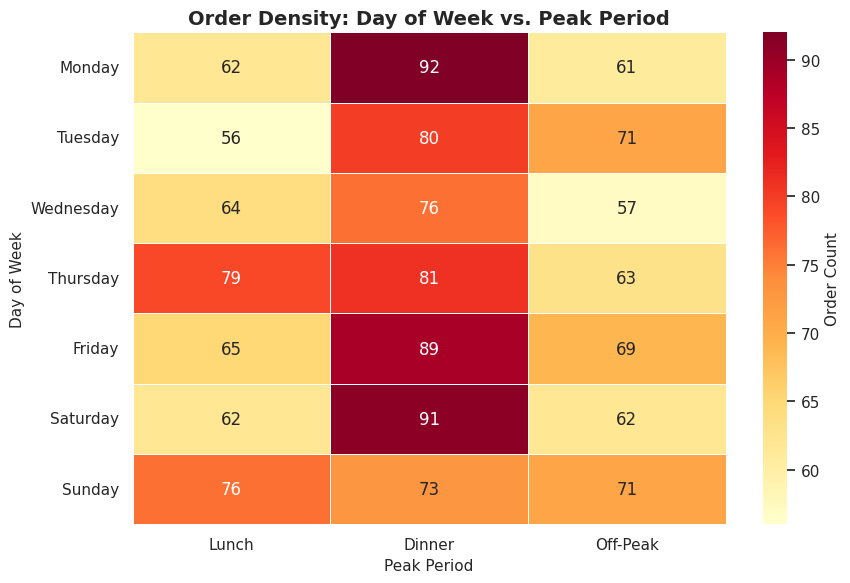

In [15]:
# ---------------------------------------------------------
# 3.1c Heatmap: order density by Day of Week x Peak Period
# ---------------------------------------------------------
heat_data = df.groupby(["Day_of_Week", "Peak_Period"], observed=True).size().unstack(fill_value=0)
heat_data = heat_data[["Lunch", "Dinner", "Off-Peak"]]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heat_data, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax, cbar_kws={"label": "Order Count"})
ax.set_title("Order Density: Day of Week vs. Peak Period")
ax.set_xlabel("Peak Period")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.show()

### 3.2 Geographical / Zone Analysis

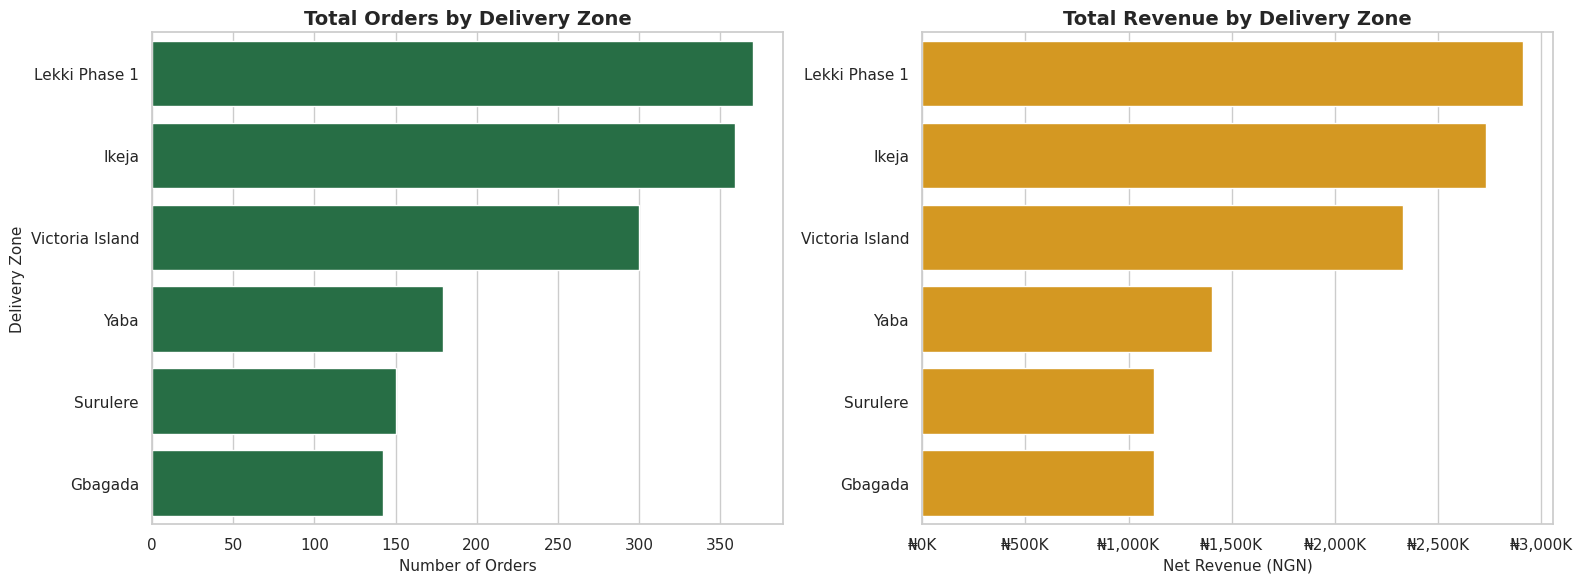

,Total_Orders,Total_Revenue,Avg_Order_Value
Delivery_Zone,,,
Lekki Phase 1,370,"₦2,910,000","₦7,865"
Ikeja,359,"₦2,734,100","₦7,616"
Victoria Island,300,"₦2,331,700","₦7,772"
Yaba,179,"₦1,403,400","₦7,840"
Surulere,150,"₦1,125,200","₦7,501"
Gbagada,142,"₦1,125,100","₦7,923"


In [16]:
# ---------------------------------------------------------
# 3.2 Orders & revenue by delivery zone
# ---------------------------------------------------------
zone_summary = df.groupby("Delivery_Zone").agg(
    Total_Orders=("Order_ID", "count"),
    Total_Revenue=("Net_Revenue_Post_Discount", "sum"),
    Avg_Order_Value=("Net_Revenue_Post_Discount", "mean")
).sort_values("Total_Revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=zone_summary["Total_Orders"], y=zone_summary.index,
            ax=axes[0], color=BRAND_PALETTE[0])
axes[0].set_title("Total Orders by Delivery Zone")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Delivery Zone")

sns.barplot(x=zone_summary["Total_Revenue"], y=zone_summary.index,
            ax=axes[1], color=BRAND_PALETTE[1])
axes[1].set_title("Total Revenue by Delivery Zone")
axes[1].set_xlabel("Net Revenue (NGN)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₦{x/1000:,.0f}K"))

plt.tight_layout()
plt.show()

zone_summary.style.format({"Total_Revenue": "₦{:,.0f}", "Avg_Order_Value": "₦{:,.0f}"})

### 3.3 Menu & Cuisine Performance

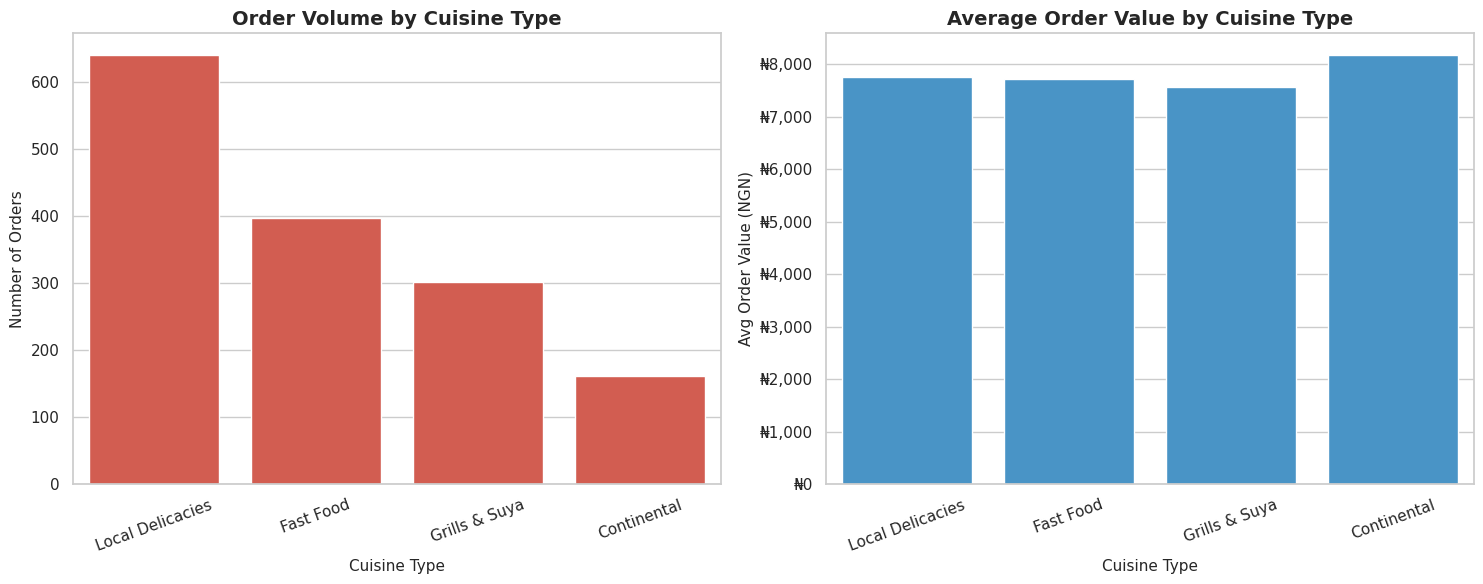

,Total_Orders,Avg_Order_Value,Total_Revenue
Cuisine_Type,,,
Local Delicacies,640,"₦7,760","₦4,966,300"
Fast Food,397,"₦7,713","₦3,062,200"
Grills & Suya,302,"₦7,565","₦2,284,500"
Continental,161,"₦8,177","₦1,316,500"


In [17]:
# ---------------------------------------------------------
# 3.3a Cuisine performance — volume vs. average order value
# ---------------------------------------------------------
cuisine_summary = df.groupby("Cuisine_Type").agg(
    Total_Orders=("Order_ID", "count"),
    Avg_Order_Value=("Net_Revenue_Post_Discount", "mean"),
    Total_Revenue=("Net_Revenue_Post_Discount", "sum")
).sort_values("Total_Orders", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=cuisine_summary.index, y=cuisine_summary["Total_Orders"],
            ax=axes[0], color=BRAND_PALETTE[3])
axes[0].set_title("Order Volume by Cuisine Type")
axes[0].set_xlabel("Cuisine Type")
axes[0].set_ylabel("Number of Orders")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(x=cuisine_summary.index, y=cuisine_summary["Avg_Order_Value"],
            ax=axes[1], color=BRAND_PALETTE[4])
axes[1].set_title("Average Order Value by Cuisine Type")
axes[1].set_xlabel("Cuisine Type")
axes[1].set_ylabel("Avg Order Value (NGN)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₦{x:,.0f}"))
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

cuisine_summary.style.format({"Avg_Order_Value": "₦{:,.0f}", "Total_Revenue": "₦{:,.0f}"})

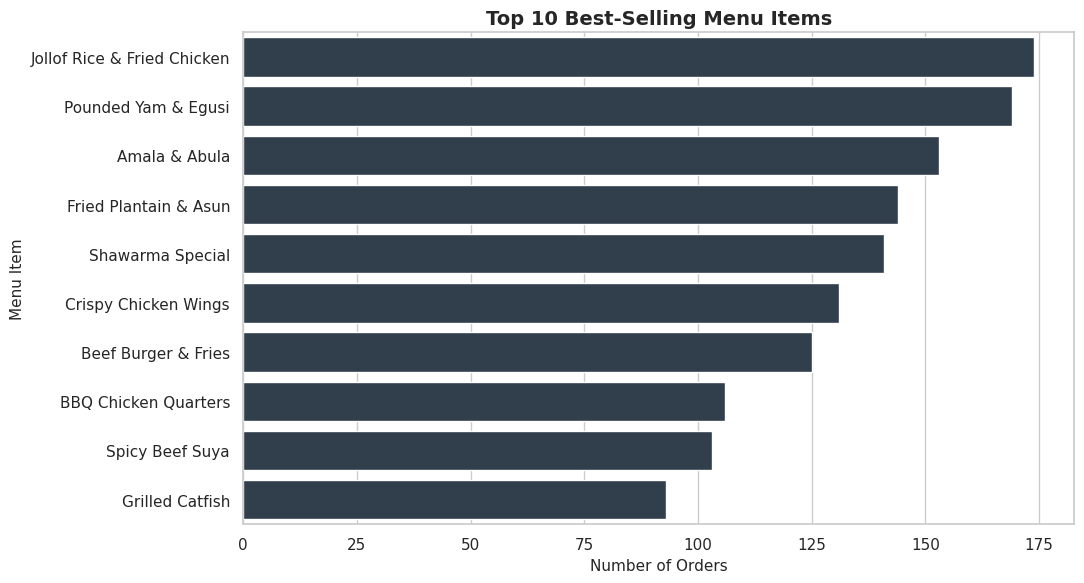

,Order_Count,Avg_Order_Value
Item_Name,,
Jollof Rice & Fried Chicken,174,"₦7,852"
Pounded Yam & Egusi,169,"₦8,141"
Amala & Abula,153,"₦7,354"
Fried Plantain & Asun,144,"₦7,632"
Shawarma Special,141,"₦7,652"
Crispy Chicken Wings,131,"₦7,692"
Beef Burger & Fries,125,"₦7,806"
BBQ Chicken Quarters,106,"₦7,377"
Spicy Beef Suya,103,"₦7,812"


In [18]:
# ---------------------------------------------------------
# 3.3b Top 10 best-selling menu items (by order volume)
# ---------------------------------------------------------
top_items = (
    df.groupby("Item_Name")
      .agg(Order_Count=("Order_ID", "count"), Avg_Order_Value=("Net_Revenue_Post_Discount", "mean"))
      .sort_values("Order_Count", ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=top_items["Order_Count"], y=top_items.index, color=BRAND_PALETTE[2], ax=ax)
ax.set_title("Top 10 Best-Selling Menu Items")
ax.set_xlabel("Number of Orders")
ax.set_ylabel("Menu Item")
plt.tight_layout()
plt.show()

top_items.style.format({"Avg_Order_Value": "₦{:,.0f}"})

### 3.4 Operational Bottlenecks & Order Status

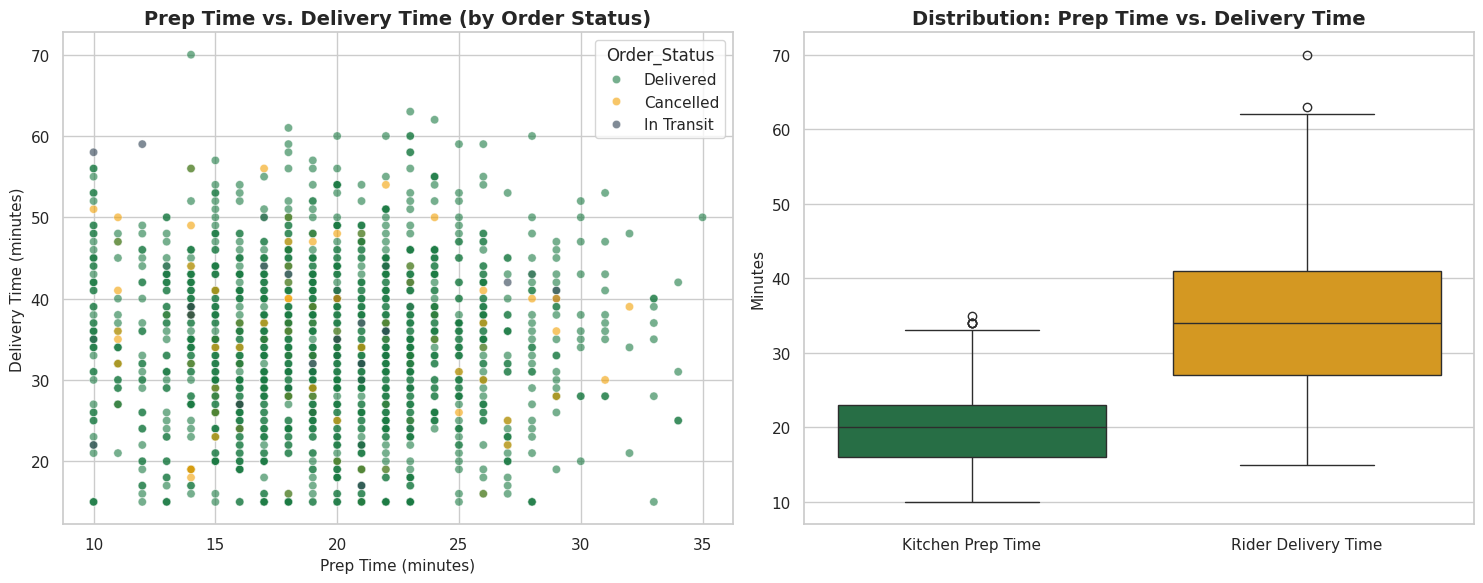

In [19]:
# ---------------------------------------------------------
# 3.4a Prep time vs. delivery time
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x="Prep_Time_Min", y="Delivery_Time_Min",
                 hue="Order_Status", alpha=0.6, ax=axes[0], palette=BRAND_PALETTE[:3])
axes[0].set_title("Prep Time vs. Delivery Time (by Order Status)")
axes[0].set_xlabel("Prep Time (minutes)")
axes[0].set_ylabel("Delivery Time (minutes)")

time_melt = df.melt(value_vars=["Prep_Time_Min", "Delivery_Time_Min"],
                     var_name="Stage", value_name="Minutes")
sns.boxplot(data=time_melt, x="Stage", y="Minutes", ax=axes[1],
            palette=[BRAND_PALETTE[0], BRAND_PALETTE[1]])
axes[1].set_title("Distribution: Prep Time vs. Delivery Time")
axes[1].set_xlabel("")
axes[1].set_ylabel("Minutes")
axes[1].set_xticklabels(["Kitchen Prep Time", "Rider Delivery Time"])

plt.tight_layout()
plt.show()

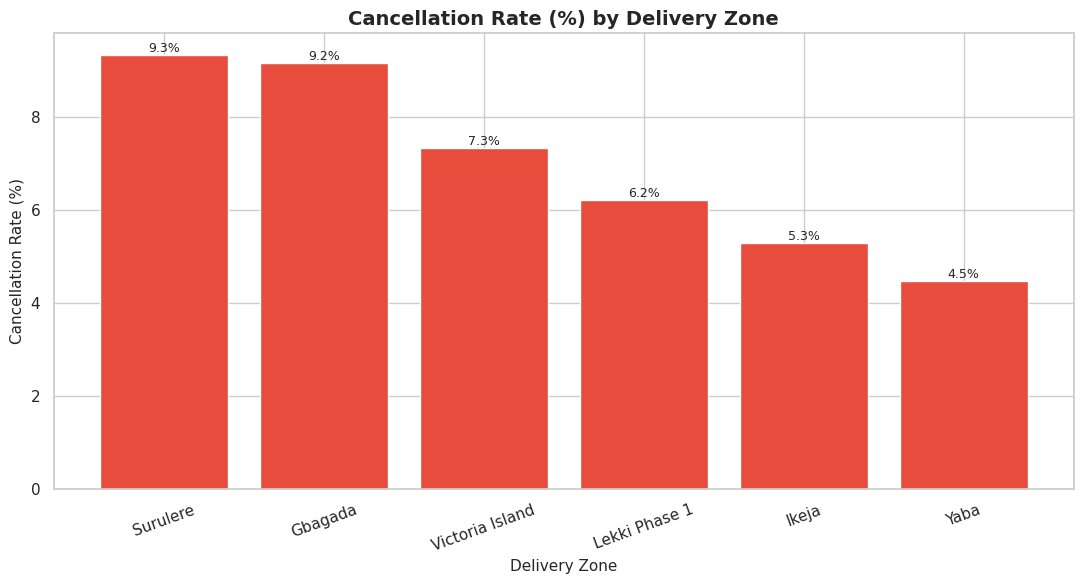

In [20]:
# ---------------------------------------------------------
# 3.4b Cancellation rate by delivery zone
# ---------------------------------------------------------
cancel_by_zone = (
    df.groupby("Delivery_Zone")["Order_Status"]
      .apply(lambda s: (s == "Cancelled").mean() * 100)
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(cancel_by_zone.index, cancel_by_zone.values, color=BRAND_PALETTE[3])
ax.set_title("Cancellation Rate (%) by Delivery Zone")
ax.set_xlabel("Delivery Zone")
ax.set_ylabel("Cancellation Rate (%)")
ax.tick_params(axis="x", rotation=20)
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{h:.1f}%", (bar.get_x() + bar.get_width() / 2, h),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

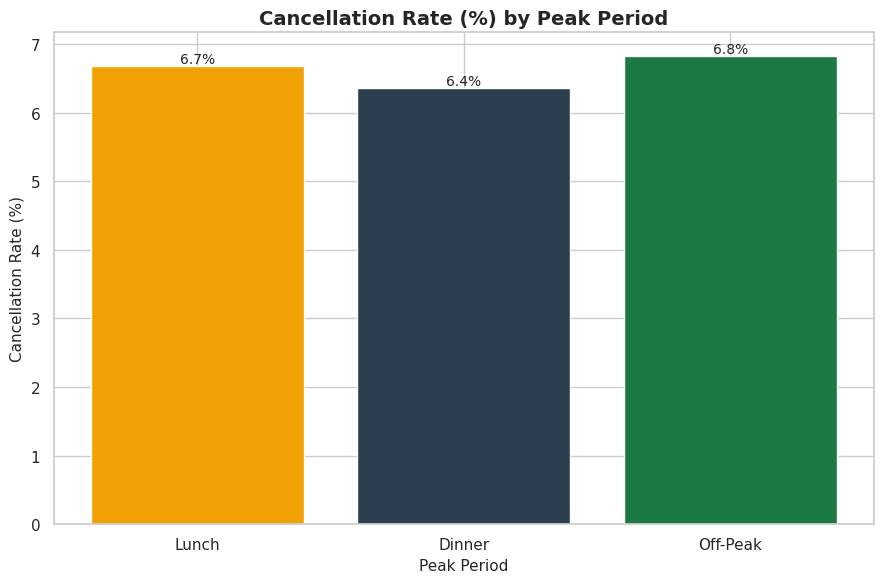

In [21]:
# ---------------------------------------------------------
# 3.4c Cancellation rate by peak period
# ---------------------------------------------------------
cancel_by_peak = (
    df.groupby("Peak_Period")["Order_Status"]
      .apply(lambda s: (s == "Cancelled").mean() * 100)
      .reindex(["Lunch", "Dinner", "Off-Peak"])
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(cancel_by_peak.index, cancel_by_peak.values,
               color=[BRAND_PALETTE[1], BRAND_PALETTE[2], BRAND_PALETTE[0]])
ax.set_title("Cancellation Rate (%) by Peak Period")
ax.set_xlabel("Peak Period")
ax.set_ylabel("Cancellation Rate (%)")
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{h:.1f}%", (bar.get_x() + bar.get_width() / 2, h),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

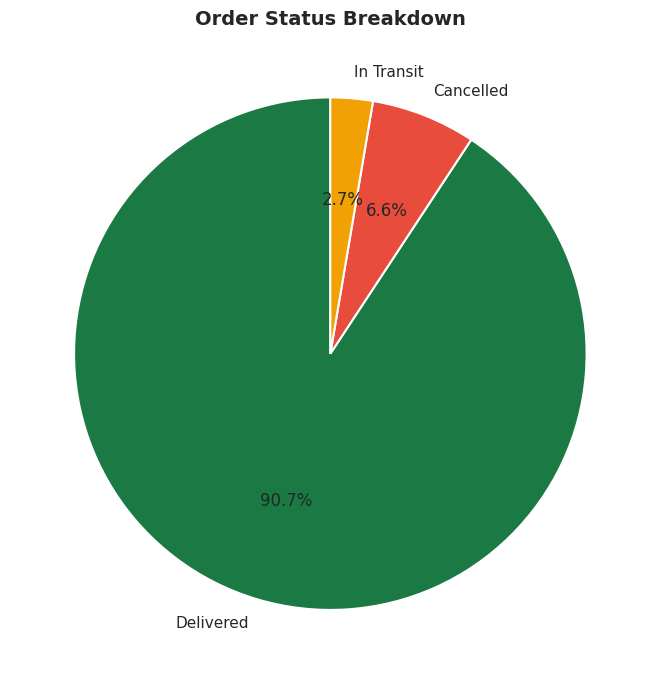

In [22]:
# ---------------------------------------------------------
# 3.4d Order status breakdown
# ---------------------------------------------------------
status_counts = df["Order_Status"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
colors = [BRAND_PALETTE[0], BRAND_PALETTE[3], BRAND_PALETTE[1]]
ax.pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%",
       colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Order Status Breakdown")
plt.tight_layout()
plt.show()

## Step 4: Executive Insights Summary & Business Metrics

Consolidated KPIs for stakeholder reporting — total revenue, order volume, AOV, cancellation rate, average delivery time, and best/worst performing zones.

In [23]:
# ---------------------------------------------------------
# 4.1 Core business metrics
# ---------------------------------------------------------
total_orders = len(df)
delivered_df = df[df["Order_Status"] == "Delivered"]

total_revenue = delivered_df["Net_Revenue_Post_Discount"].sum()
avg_order_value = delivered_df["Net_Revenue_Post_Discount"].mean()
cancellation_rate = (df["Order_Status"] == "Cancelled").mean() * 100
avg_delivery_time = df["Delivery_Time_Min"].mean()
avg_prep_time = df["Prep_Time_Min"].mean()
avg_rating = df.loc[df["Has_Rating"], "Customer_Rating"].mean()

most_profitable_zone = zone_summary["Total_Revenue"].idxmax()
slowest_zone = df.groupby("Delivery_Zone")["Delivery_Time_Min"].mean().idxmax()
fastest_zone = df.groupby("Delivery_Zone")["Delivery_Time_Min"].mean().idxmin()

executive_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Revenue (Delivered Orders, NGN)",
        "Average Order Value (AOV, NGN)",
        "Overall Cancellation Rate (%)",
        "Average Prep Time (min)",
        "Average Delivery Time (min)",
        "Average Customer Rating (out of 5)",
        "Most Profitable Zone",
        "Slowest Delivery Zone (avg time)",
        "Fastest Delivery Zone (avg time)",
    ],
    "Value": [
        f"{total_orders:,}",
        f"₦{total_revenue:,.0f}",
        f"₦{avg_order_value:,.0f}",
        f"{cancellation_rate:.2f}%",
        f"{avg_prep_time:.1f} min",
        f"{avg_delivery_time:.1f} min",
        f"{avg_rating:.2f} / 5",
        most_profitable_zone,
        slowest_zone,
        fastest_zone,
    ]
})

print("=" * 60)
print("   EXECUTIVE SUMMARY — DA-19 FOOD DELIVERY ANALYSIS")
print("=" * 60)
executive_summary

   EXECUTIVE SUMMARY — DA-19 FOOD DELIVERY ANALYSIS


,Metric,Value
0,Total Orders,"1,500"
1,"Total Revenue (Delivered Orders, NGN)","₦10,537,300"
2,"Average Order Value (AOV, NGN)","₦7,742"
3,Overall Cancellation Rate (%),6.60%
4,Average Prep Time (min),19.6 min
5,Average Delivery Time (min),34.3 min
6,Average Customer Rating (out of 5),4.23 / 5
7,Most Profitable Zone,Lekki Phase 1
8,Slowest Delivery Zone (avg time),Lekki Phase 1
9,Fastest Delivery Zone (avg time),Surulere


In [24]:
# ---------------------------------------------------------
# 4.2 Zone performance matrix (profitability vs. speed)
# ---------------------------------------------------------
zone_matrix = df.groupby("Delivery_Zone").agg(
    Total_Orders=("Order_ID", "count"),
    Total_Revenue=("Net_Revenue_Post_Discount", "sum"),
    Avg_Delivery_Time=("Delivery_Time_Min", "mean"),
    Cancellation_Rate_pct=("Order_Status", lambda s: (s == "Cancelled").mean() * 100)
).round(1).sort_values("Total_Revenue", ascending=False)

zone_matrix.style.format({
    "Total_Revenue": "₦{:,.0f}",
    "Avg_Delivery_Time": "{:.1f} min",
    "Cancellation_Rate_pct": "{:.1f}%"
})

,Total_Orders,Total_Revenue,Avg_Delivery_Time,Cancellation_Rate_pct
Delivery_Zone,,,,
Lekki Phase 1,370,"₦2,910,000",34.9 min,6.2%
Ikeja,359,"₦2,734,100",34.8 min,5.3%
Victoria Island,300,"₦2,331,700",34.4 min,7.3%
Yaba,179,"₦1,403,400",33.9 min,4.5%
Surulere,150,"₦1,125,200",33.2 min,9.3%
Gbagada,142,"₦1,125,100",33.3 min,9.2%


## Step 5: Strategic Business Recommendations

Based on the operational, spatial, and financial patterns uncovered in Steps 3–4, the following recommendations are proposed for vendors and platform operators:

1. **Dynamic Kitchen Staffing for Peak Windows** — Lunch (12:00–15:00) and Dinner (18:00–21:00) periods consistently show the highest order density and elevated prep times. Vendors should schedule additional kitchen staff during these windows to reduce prep-time bottlenecks and prevent order backlogs.

2. **Zone-Targeted Rider Allocation** — Zones with above-average delivery times (see Section 4.2) should receive a higher rider-to-order ratio or dedicated riders during peak hours, rather than a uniform city-wide allocation. This directly targets the slowest-performing zone identified in the executive summary.

3. **Cancellation-Driven Root Cause Review** — Zones and peak periods with disproportionately high cancellation rates should be investigated for underlying causes (e.g., long wait estimates, stockouts, rider shortages) rather than addressed with blanket discounting, since cancellations concentrated in specific zones/periods point to operational rather than pricing issues.

4. **Menu Curation Around Top Performers** — Promotional placement, upsell prompts, and bundle offers should be concentrated on the top-performing cuisines and items identified in Section 3.3, since a small set of items drives a disproportionate share of order volume.

5. **Discount Strategy Refinement** — Rather than applying discounts uniformly, discount spend should be reallocated toward off-peak hours and underperforming zones to smooth demand throughout the day and stimulate orders where volume is naturally lower, protecting margin during already-high-demand peak windows.


## Step 6: Dataset Export

Export the cleaned, feature-engineered dataset to Excel so it is ready to be connected directly to Power BI or Tableau for interactive dashboarding.

In [25]:
# ---------------------------------------------------------
# 6.1 Export cleaned & feature-engineered dataset
# ---------------------------------------------------------
export_df = df.copy()

# Convert Order_Date back to a proper datetime for Excel/Power BI compatibility
export_df["Order_Date"] = pd.to_datetime(export_df["Order_Date"])

OUTPUT_PATH = "Cleaned_Nigerian_Food_Delivery_Orders.xlsx"

with pd.ExcelWriter(OUTPUT_PATH, engine="xlsxwriter") as writer:
    export_df.to_excel(writer, sheet_name="Cleaned_Orders", index=False)
    executive_summary.to_excel(writer, sheet_name="Executive_Summary", index=False)
    zone_matrix.reset_index().to_excel(writer, sheet_name="Zone_Performance", index=False)
    cuisine_summary.reset_index().to_excel(writer, sheet_name="Cuisine_Performance", index=False)

print(f"Export complete -> '{OUTPUT_PATH}'")
print(f"Sheets written: Cleaned_Orders, Executive_Summary, Zone_Performance, Cuisine_Performance")
print(f"Final exported shape: {export_df.shape[0]:,} rows x {export_df.shape[1]} columns")

Export complete -> 'Cleaned_Nigerian_Food_Delivery_Orders.xlsx'
Sheets written: Cleaned_Orders, Executive_Summary, Zone_Performance, Cuisine_Performance
Final exported shape: 1,500 rows x 23 columns


---

### Notebook Complete ✅

This notebook has produced:
- A fully cleaned and feature-engineered dataset (time features, financial KPIs, rating flags)
- Four categories of publication-ready EDA visualizations (peak time, zone, cuisine/menu, operational bottlenecks)
- An executive KPI summary table
- Five strategic, data-grounded business recommendations
- A multi-sheet Excel export (`Cleaned_Nigerian_Food_Delivery_Orders.xlsx`) ready for Power BI / Tableau dashboarding

**Next steps for the DA-19 capstone submission:** build the interactive Power BI dashboard from the exported Excel file, prepare the one-page insight summary, and record the demo video walkthrough.
